# Data Analysis PXD040621

Plan
- read data and log2 transform intensity values
- aggregate peptide intensities to protein intensities
- format data from long to wide format
- remove contaminant proteins
- check for missing values
- Clustermap of sample and proteins
- differential analysis (Volcano Plots)
- Enrichment Analysis
- check for maltose update pathway (Fig. 3 in paper)

In [1]:
%pip install acore vuecore

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import acore.differential_regulation
import acore.enrichment_analysis
import acore.normalization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats
import seaborn as sns
import vuecore
from acore.io.uniprot import fetch_annotations, process_annotations
from vuecore.viz import get_enrichment_plots

# Read in the data
- `file_in`: input file with the quantified peptide data in MSstats format
   as provided by quantms

The file will be loaded from the repository if it is not present.

In [3]:
file_in = Path("data/PXD040621/processed/PXD040621.sdrf_openms_design_msstats_in.csv")
if not file_in.exists():
    file_in = (
        "https://raw.githubusercontent.com/biosustain/dsp_course_proteomics_intro/HEAD"
        "/data/PXD040621/processed/PXD040621.sdrf_openms_design_msstats_in.csv"
    )
df = pd.read_csv(file_in, sep=",", header=0)  # .set_index([])
df.head()

,ProteinName,PeptideSequence,PrecursorCharge,FragmentIon,ProductCharge,IsotopeLabelType,Condition,BioReplicate,Run,Intensity,Reference
0,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,1,1,"201,065,600.000",20220830_JL-4884_Forster_Ecoli_DMSO_rep1_EG-1....
1,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,2,2,"74,844,780.000",20220830_JL-4884_Forster_Ecoli_DMSO_rep2_EG-2....
2,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,3,3,"67,591,390.000",20220830_JL-4884_Forster_Ecoli_DMSO_rep3_EG-3....
3,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,4,4,"76,388,810.000",20220830_JL-4884_Forster_Ecoli_DMSO_rep4_EG-4....
4,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Sulforaphane,5,5,"116,247,100.000",20220830_JL-4884_Forster_Ecoli_Suf_rep1_EG-5.mzML


In [4]:
# Parameters
file_in = "PXD040621.sdrf_openms_design_msstats_in.csv"


define the output folder for our VueGen report which we will create later

In [5]:
out_dir = "report_files"
out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

We have the following columns in the data:

```python
cols = [
    "ProteinName",
    "PeptideSequence",
    "PrecursorCharge",
    "FragmentIon",
    "ProductCharge",
    "IsotopeLabelType",
    "Condition",
    "BioReplicate",
    "Run",
    "Intensity",
    "Reference",
]

# Log2 transform the intensity values
- log2 transformations are common for lognormal distributed data

In [6]:
df["Intensity"] = np.log2(df["Intensity"].astype(float))
df.head()

,ProteinName,PeptideSequence,PrecursorCharge,FragmentIon,ProductCharge,IsotopeLabelType,Condition,BioReplicate,Run,Intensity,Reference
0,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,1,1,27.583,20220830_JL-4884_Forster_Ecoli_DMSO_rep1_EG-1....
1,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,2,2,26.157,20220830_JL-4884_Forster_Ecoli_DMSO_rep2_EG-2....
2,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,3,3,26.010,20220830_JL-4884_Forster_Ecoli_DMSO_rep3_EG-3....
3,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Control,4,4,26.187,20220830_JL-4884_Forster_Ecoli_DMSO_rep4_EG-4....
4,sp|P00959|SYM_ECOLI,AAAAPVTGPLADDPIQETITFDDFAK,2,NaN,0,L,Sulforaphane,5,5,26.793,20220830_JL-4884_Forster_Ecoli_Suf_rep1_EG-5.mzML


# Exploratory and Data Quality Plots (peptide level)
df["BioReplicate"] = df["BioReplicate"].replace({5: 1, 6: 2, 7: 3, 8: 4})
fg = sns.displot(
    data=df.rename(columns={"BioReplicate": "Rep", "Condition": "C."}),
    x="Intensity",
    col="C.",
    row="Rep",
    # hue="Reactor_ID",
    kind="kde",
    height=2,
    aspect=1.1,
)

# Aggregate the peptide intensities to protein intensities
- we use the median of the peptide intensities for each protein

There are more sophisticated ways to do this, e.g. using MaxLFQ, iBAQ, FlashLFQ, DirectLFQ, etc.

- shorten sample name for readability

In [7]:
proteins = (
    df.groupby(["ProteinName", "Reference"])["Intensity"].median().unstack(level=0)
)
proteins.index = proteins.index.str.split("_").str[4:6].str.join("_")
proteins

ProteinName,CON_ENSEMBL:ENSBTAP00000024462;CON_ENSEMBL:ENSBTAP00000024466,CON_O76013,CON_P00761,CON_P01966,CON_P02070,CON_P02533,CON_P02538,CON_P02662,CON_P02663,CON_P02666,...,sp|Q47319|TAPT_ECOLI,sp|Q47536|YAIP_ECOLI,sp|Q47622|SAPA_ECOLI,sp|Q47679|YAFV_ECOLI,sp|Q47710|YQJK_ECOLI,sp|Q57261|TRUD_ECOLI,sp|Q59385-2|COPA_ECOLI,sp|Q59385|COPA_ECOLI,sp|Q7DFV3|YMGG_ECOLI,sp|Q93K97|ADPP_ECOLI
Reference,,,,,,,,,,,,,,,,,,,,,
DMSO_rep1,NaN,NaN,31.055,24.202,26.890,28.336,25.828,NaN,26.762,NaN,...,NaN,NaN,25.343,NaN,27.038,28.411,23.555,27.640,28.513,27.223
DMSO_rep2,NaN,25.647,30.117,25.711,NaN,25.595,26.210,NaN,27.593,NaN,...,NaN,NaN,NaN,NaN,26.841,27.941,25.240,27.244,27.621,25.291
DMSO_rep3,25.529,NaN,33.767,NaN,NaN,26.992,25.441,28.129,28.895,29.559,...,NaN,NaN,24.576,NaN,26.609,27.070,NaN,27.525,27.679,24.359
DMSO_rep4,NaN,NaN,33.702,NaN,NaN,27.205,26.093,NaN,27.764,NaN,...,NaN,NaN,25.945,23.902,27.164,26.680,22.524,27.404,27.256,25.767
Suf_rep1,NaN,NaN,34.068,NaN,NaN,NaN,24.442,NaN,25.938,NaN,...,NaN,NaN,25.836,NaN,26.819,27.995,NaN,27.499,28.090,25.956
Suf_rep2,NaN,NaN,33.252,NaN,26.571,26.495,25.070,NaN,NaN,NaN,...,NaN,NaN,NaN,24.162,27.268,27.055,NaN,27.667,27.526,25.231
Suf_rep3,NaN,NaN,31.844,25.927,NaN,26.249,28.169,22.968,26.466,NaN,...,25.463,NaN,NaN,NaN,24.741,27.313,NaN,27.708,27.814,26.103
Suf_rep4,NaN,NaN,33.857,NaN,NaN,27.208,24.690,NaN,NaN,NaN,...,NaN,24.468,24.757,24.040,27.071,26.643,NaN,27.848,27.605,26.178


# Remove contaminant proteins
Remove the contaminant proteins which were added to the fasta file used in the data processing.
Contaminant proteins are e.g. creation which gets into the sample from the human skin or hair
when the sample is prepared.

These are filtered out as they are most of the time not relevant, but a contamination.

In [8]:
decoy_proteins = proteins.filter(like="CON_", axis=1)
proteins = proteins.drop(decoy_proteins.columns, axis=1)
proteins

ProteinName,sp|A5A613|YCIY_ECOLI,sp|P00350|6PGD_ECOLI,sp|P00363|FRDA_ECOLI,sp|P00370|DHE4_ECOLI,sp|P00393|NDH_ECOLI,sp|P00448|SODM_ECOLI,sp|P00452|RIR1_ECOLI,sp|P00490|PHSM_ECOLI,sp|P00509|AAT_ECOLI,sp|P00547|KHSE_ECOLI,...,sp|Q47319|TAPT_ECOLI,sp|Q47536|YAIP_ECOLI,sp|Q47622|SAPA_ECOLI,sp|Q47679|YAFV_ECOLI,sp|Q47710|YQJK_ECOLI,sp|Q57261|TRUD_ECOLI,sp|Q59385-2|COPA_ECOLI,sp|Q59385|COPA_ECOLI,sp|Q7DFV3|YMGG_ECOLI,sp|Q93K97|ADPP_ECOLI
Reference,,,,,,,,,,,,,,,,,,,,,
DMSO_rep1,27.180,28.152,30.247,27.459,26.824,25.610,NaN,27.864,29.979,26.065,...,NaN,NaN,25.343,NaN,27.038,28.411,23.555,27.640,28.513,27.223
DMSO_rep2,NaN,27.926,30.262,26.873,26.757,24.901,NaN,26.439,29.048,NaN,...,NaN,NaN,NaN,NaN,26.841,27.941,25.240,27.244,27.621,25.291
DMSO_rep3,NaN,27.653,29.970,26.600,25.442,25.054,27.172,26.382,28.777,NaN,...,NaN,NaN,24.576,NaN,26.609,27.070,NaN,27.525,27.679,24.359
DMSO_rep4,NaN,27.152,29.471,26.439,25.799,24.790,NaN,26.820,29.485,25.524,...,NaN,NaN,25.945,23.902,27.164,26.680,22.524,27.404,27.256,25.767
Suf_rep1,NaN,27.442,30.005,27.400,26.671,25.564,NaN,27.685,29.295,NaN,...,NaN,NaN,25.836,NaN,26.819,27.995,NaN,27.499,28.090,25.956
Suf_rep2,NaN,27.032,30.086,27.189,26.886,25.378,27.364,27.531,29.284,NaN,...,NaN,NaN,NaN,24.162,27.268,27.055,NaN,27.667,27.526,25.231
Suf_rep3,NaN,27.815,29.904,27.139,26.711,25.318,26.062,27.545,29.357,26.265,...,25.463,NaN,NaN,NaN,24.741,27.313,NaN,27.708,27.814,26.103
Suf_rep4,NaN,27.587,29.575,27.224,26.321,25.360,25.101,27.705,29.584,26.427,...,NaN,24.468,24.757,24.040,27.071,26.643,NaN,27.848,27.605,26.178


Create a label for each sample based on the metadata.
- we will use a string in the sample name, but you can see how the metadata is organized

In [9]:
meta = df[["Condition", "BioReplicate", "Run", "Reference"]].drop_duplicates()
meta

,Condition,BioReplicate,Run,Reference
0,Control,1,1,20220830_JL-4884_Forster_Ecoli_DMSO_rep1_EG-1....
1,Control,2,2,20220830_JL-4884_Forster_Ecoli_DMSO_rep2_EG-2....
2,Control,3,3,20220830_JL-4884_Forster_Ecoli_DMSO_rep3_EG-3....
3,Control,4,4,20220830_JL-4884_Forster_Ecoli_DMSO_rep4_EG-4....
4,Sulforaphane,5,5,20220830_JL-4884_Forster_Ecoli_Suf_rep1_EG-5.mzML
5,Sulforaphane,6,6,20220830_JL-4884_Forster_Ecoli_Suf_rep2_EG-6.mzML
6,Sulforaphane,7,7,20220830_JL-4884_Forster_Ecoli_Suf_rep3_EG-7.mzML
7,Sulforaphane,8,8,20220830_JL-4884_Forster_Ecoli_Suf_rep4_EG-8.mzML


In [10]:
label_encoding = {0: "control", 1: "10 µm sulforaphane"}
label_suf = pd.Series(
    proteins.index.str.contains("Suf_").astype(int),
    index=proteins.index,
    name="label_suf",
    dtype=np.int8,
).map(label_encoding)
label_suf

Reference
DMSO_rep1               control
DMSO_rep2               control
DMSO_rep3               control
DMSO_rep4               control
Suf_rep1     10 µm sulforaphane
Suf_rep2     10 µm sulforaphane
Suf_rep3     10 µm sulforaphane
Suf_rep4     10 µm sulforaphane
Name: label_suf, dtype: object

# Plot the data completeness for each protein.

In [11]:
view_name = "Protein"
out_dir_subsection = out_dir / "1_data" / "completeness"
out_dir_subsection.mkdir(parents=True, exist_ok=True)

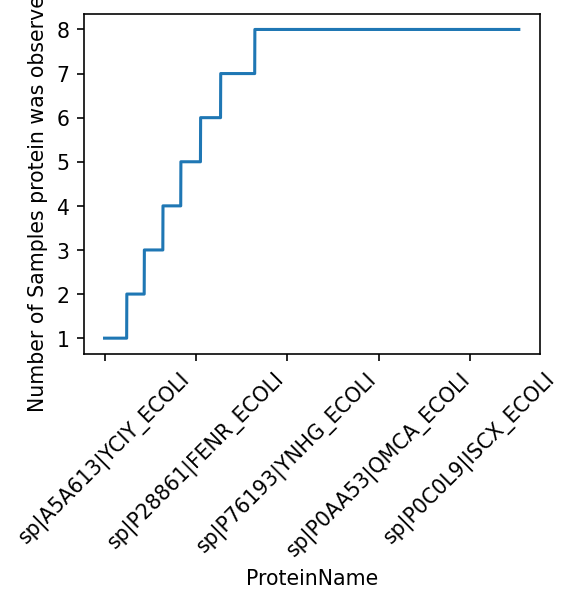

In [12]:
view_name = "Protein"
ax = (
    proteins.notna()
    .sum()
    .sort_values()
    .plot(
        rot=45,
        ylabel=f"Number of Samples {view_name.lower()} was observed in",
    )
)
ax.get_figure().savefig(
    out_dir_subsection / f"data_completeness_step_plot.png",
    bbox_inches="tight",
    dpi=300,
)

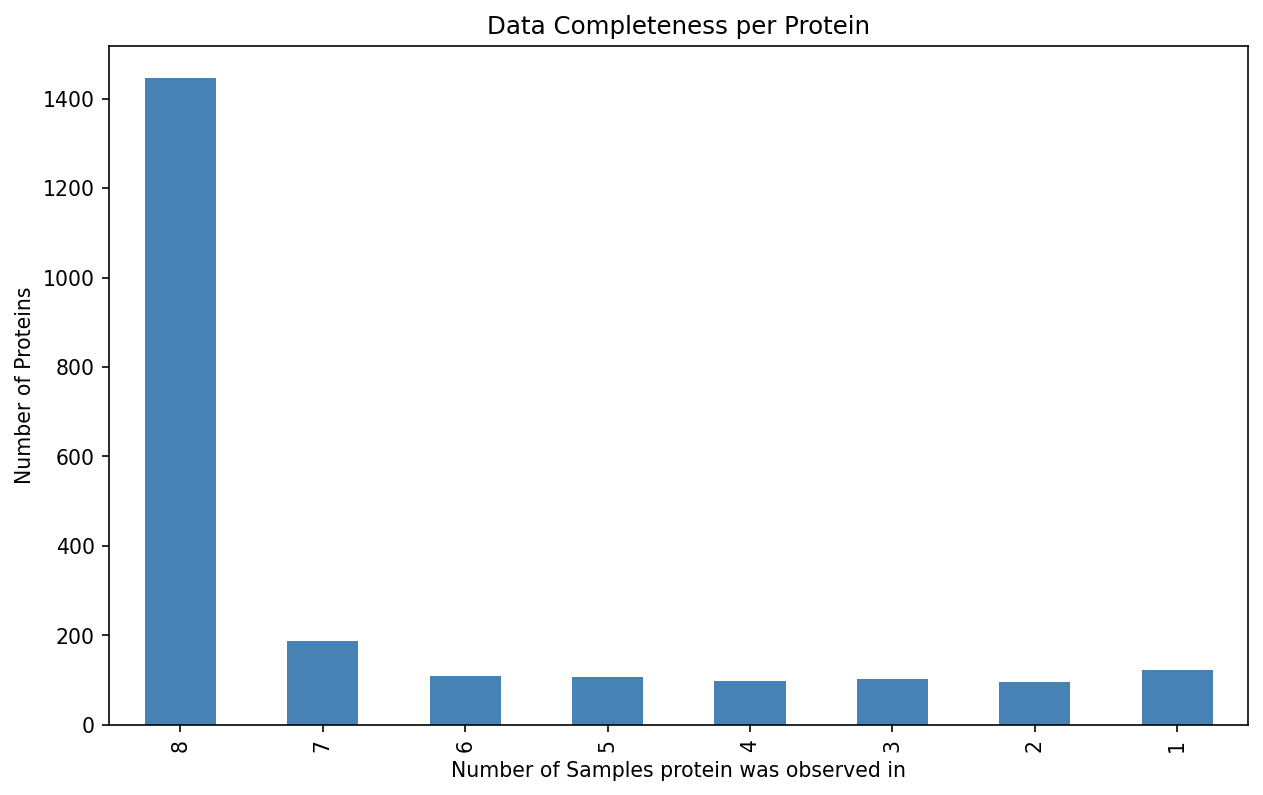

In [13]:
view_name = "Protein"
ax = (
    proteins.notna()
    .sum()
    .value_counts()
    .sort_index(ascending=False)
    .plot(
        kind="bar",
        title=f"Data Completeness per {view_name}",
        xlabel=f"Number of Samples {view_name.lower()} was observed in",
        ylabel=f"Number of {view_name}s",
        color="steelblue",
        figsize=(10, 6),
    )
)
ax.get_figure().savefig(
    out_dir_subsection / f"data_completeness_bar_plot.png",
    bbox_inches="tight",
    dpi=300,
)

In [14]:
# Explode column names to examine split by '|'
proteins_meta = (
    proteins.columns.str.split("|", expand=True)
    .to_frame()
    .dropna(how="any", axis=1)
    .reset_index(drop=True)
)
proteins_meta.columns = ["Source", "ProteinName", "GeneName"]
proteins_meta["GeneName"] = proteins_meta["GeneName"].str.split("_").str[0]
proteins_meta.index = proteins.columns
proteins_meta.index.name = "identifier"
proteins_meta

,Source,ProteinName,GeneName
identifier,,,
sp|A5A613|YCIY_ECOLI,sp,A5A613,YCIY
sp|P00350|6PGD_ECOLI,sp,P00350,6PGD
sp|P00363|FRDA_ECOLI,sp,P00363,FRDA
sp|P00370|DHE4_ECOLI,sp,P00370,DHE4
sp|P00393|NDH_ECOLI,sp,P00393,NDH
...,...,...,...
sp|Q57261|TRUD_ECOLI,sp,Q57261,TRUD
sp|Q59385-2|COPA_ECOLI,sp,Q59385-2,COPA
sp|Q59385|COPA_ECOLI,sp,Q59385,COPA


For later in the enrichment analysis let's replace the protein identifier from the Fasta
file with the UNIPROT ID

In [15]:
proteins.columns = proteins_meta["ProteinName"].rename("UniprotID")
proteins

UniprotID,A5A613,P00350,P00363,P00370,P00393,P00448,P00452,P00490,P00509,P00547,...,Q47319,Q47536,Q47622,Q47679,Q47710,Q57261,Q59385-2,Q59385,Q7DFV3,Q93K97
Reference,,,,,,,,,,,,,,,,,,,,,
DMSO_rep1,27.180,28.152,30.247,27.459,26.824,25.610,NaN,27.864,29.979,26.065,...,NaN,NaN,25.343,NaN,27.038,28.411,23.555,27.640,28.513,27.223
DMSO_rep2,NaN,27.926,30.262,26.873,26.757,24.901,NaN,26.439,29.048,NaN,...,NaN,NaN,NaN,NaN,26.841,27.941,25.240,27.244,27.621,25.291
DMSO_rep3,NaN,27.653,29.970,26.600,25.442,25.054,27.172,26.382,28.777,NaN,...,NaN,NaN,24.576,NaN,26.609,27.070,NaN,27.525,27.679,24.359
DMSO_rep4,NaN,27.152,29.471,26.439,25.799,24.790,NaN,26.820,29.485,25.524,...,NaN,NaN,25.945,23.902,27.164,26.680,22.524,27.404,27.256,25.767
Suf_rep1,NaN,27.442,30.005,27.400,26.671,25.564,NaN,27.685,29.295,NaN,...,NaN,NaN,25.836,NaN,26.819,27.995,NaN,27.499,28.090,25.956
Suf_rep2,NaN,27.032,30.086,27.189,26.886,25.378,27.364,27.531,29.284,NaN,...,NaN,NaN,NaN,24.162,27.268,27.055,NaN,27.667,27.526,25.231
Suf_rep3,NaN,27.815,29.904,27.139,26.711,25.318,26.062,27.545,29.357,26.265,...,25.463,NaN,NaN,NaN,24.741,27.313,NaN,27.708,27.814,26.103
Suf_rep4,NaN,27.587,29.575,27.224,26.321,25.360,25.101,27.705,29.584,26.427,...,NaN,24.468,24.757,24.040,27.071,26.643,NaN,27.848,27.605,26.178


And let's save a table with the data for inspection

In [16]:
proteins_meta.to_csv(out_dir_subsection / "proteins_identifiers.csv")
proteins.to_csv(out_dir_subsection / "proteins.csv")

# Hierarchical Clustering of data
- using completely observed data only
Find correlations in data

In [17]:
out_dir_subsection = out_dir / "1_data" / "clustermap"
out_dir_subsection.mkdir(parents=True, exist_ok=True)

In [18]:
_group_labels = label_encoding.values()
lut = dict(zip(_group_labels, [f"C{i}" for i in range(len(_group_labels))]))
row_colors = label_suf.map(lut).rename("group color")
row_colors

Reference
DMSO_rep1    C0
DMSO_rep2    C0
DMSO_rep3    C0
DMSO_rep4    C0
Suf_rep1     C1
Suf_rep2     C1
Suf_rep3     C1
Suf_rep4     C1
Name: group color, dtype: object

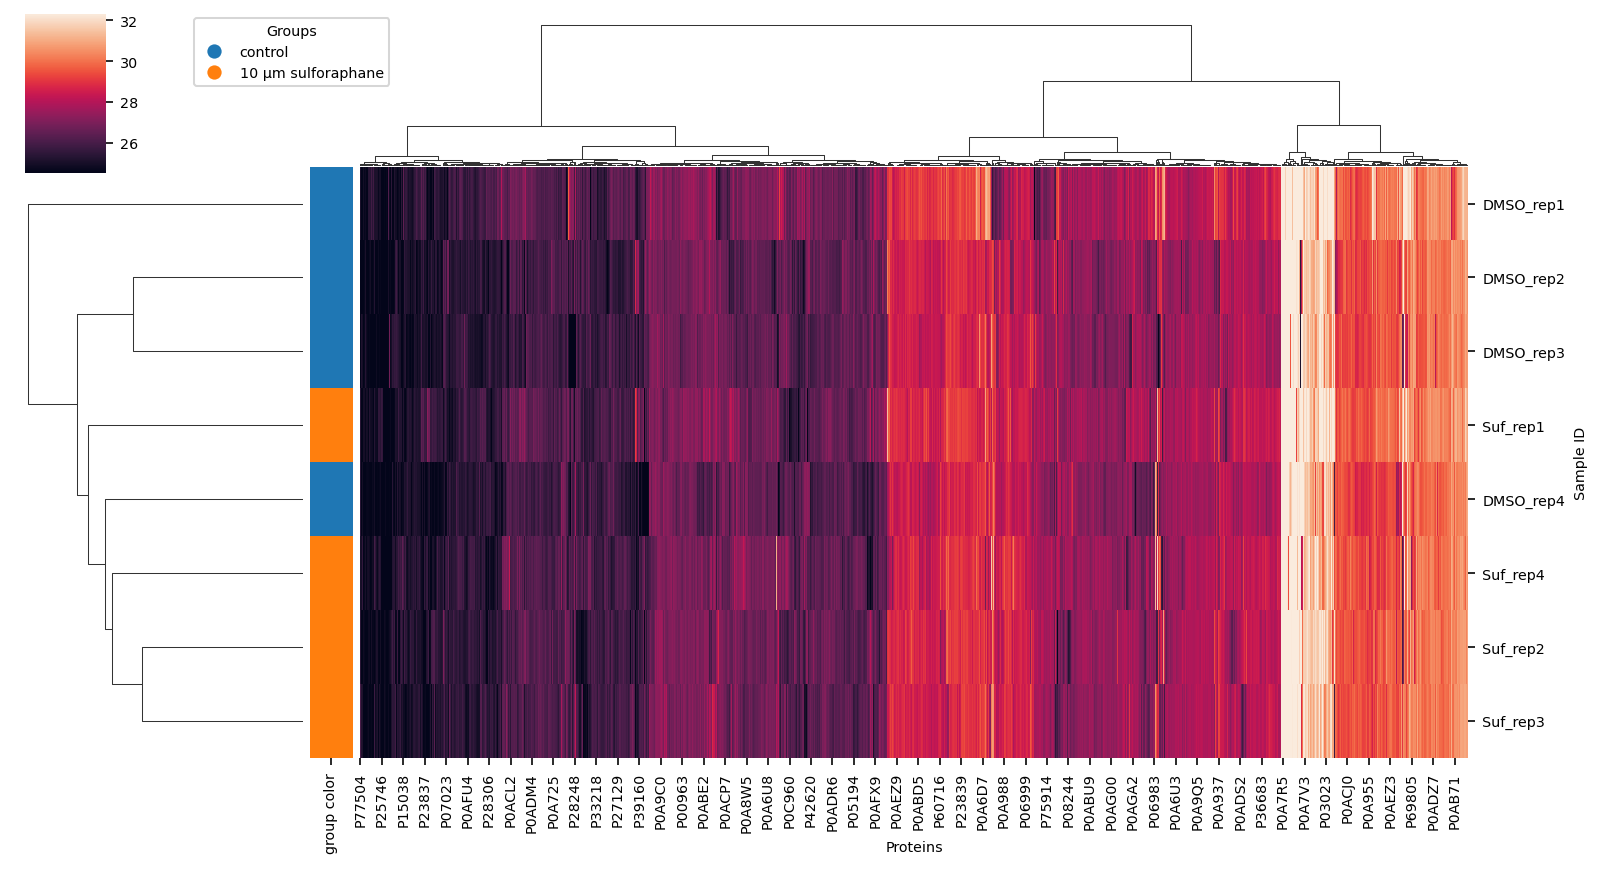

In [19]:
vuecore.set_font_sizes(7)
cg = sns.clustermap(
    proteins.dropna(how="any", axis=1),
    method="ward",
    row_colors=row_colors,
    figsize=(11, 6),
    robust=True,
    xticklabels=True,
    yticklabels=True,
)
fig = cg.figure
cg.ax_heatmap.set_xlabel("Proteins")
cg.ax_heatmap.set_ylabel("Sample ID")
vuecore.select_xticks(cg.ax_heatmap)
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=lut[name], markersize=8)
    for name in lut
]
cg.ax_cbar.legend(
    handles, _group_labels, title="Groups", loc="lower left", bbox_to_anchor=(2, 0.5)
)
fname = out_dir_subsection / "clustermap_ward.png"
# vuecore.savefig(fig, fname, pdf=True, dpi=600, tight_layout=False)
fig.savefig(
    out_dir_subsection / "clustermap_ward.png",
    bbox_inches="tight",
    dpi=300,
)

## Analytical Plots
- data distribution (e.g. histogram)
- coefficient of variation (CV)
- number of identified proteins per sample

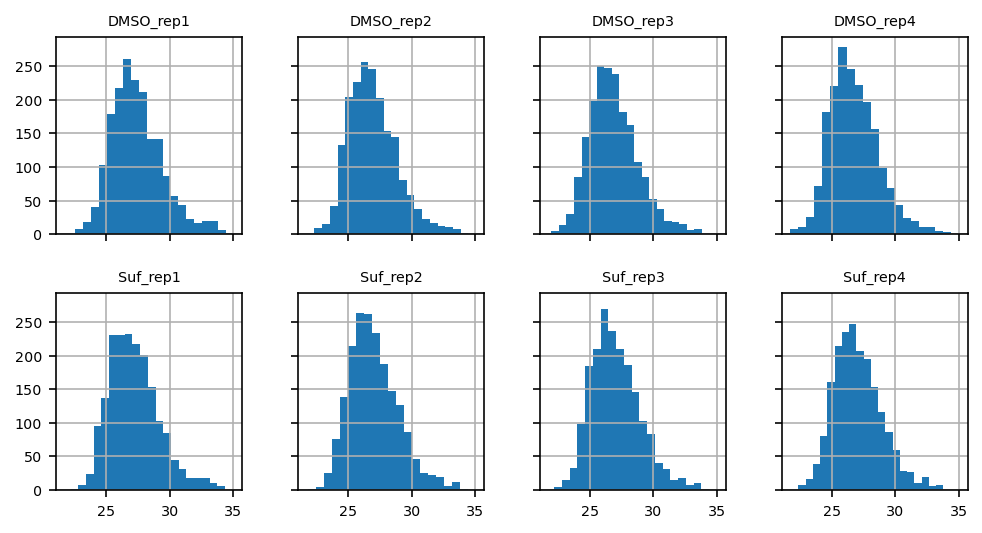

In [20]:
# ToDo: bin width functionaity: bins should match between all plots (see pimms)
ax = proteins.T.hist(layout=(2, 4), bins=20, sharex=True, sharey=True, figsize=(8, 4))

# Coefficient of Variation (CV)
- CV = standard deviation / mean
- per group

In [21]:
df_cvs = (
    proteins.groupby(label_suf)  # .join(metadata[grouping])
    # .agg(scipy.stats.variation)
    .agg([scipy.stats.variation, "mean"])  # .rename_axis(["feat", "stat"], axis=1)
)
df_cvs

UniprotID             A5A613           P00350           P00363         \
                   variation   mean variation   mean variation   mean   
label_suf                                                               
10 µm sulforaphane       NaN    NaN     0.010 27.469     0.006 29.892   
control                  NaN 27.180     0.013 27.721     0.011 29.987   

UniprotID             P00370           P00393         ...    Q57261         \
                   variation   mean variation   mean  ... variation   mean   
label_suf                                             ...                    
10 µm sulforaphane     0.004 27.238     0.008 26.647  ...     0.018 27.252   
control                0.014 26.843     0.023 26.205  ...     0.025 27.525   

UniprotID           Q59385-2           Q59385           Q7DFV3         \
                   variation   mean variation   mean variation   mean   
label_suf                                                               
10 µm sulforaphane       NaN    NaN     0.004 27.680     0.008 27.759   
control                  NaN 23.773     0.005 27.453     0.017 27.767   

UniprotID             Q93K97         
                   variation   mean  
label_suf                            
10 µm sulforaphane     0.015 25.867  
control                0.040 25.660  

[2 rows x 4538 columns]

In [22]:
df_cvs = df_cvs.stack(0, future_stack=True).reset_index().dropna()
df_cvs

,label_suf,UniprotID,variation,mean
1,10 µm sulforaphane,P00350,0.010,27.469
2,10 µm sulforaphane,P00363,0.006,29.892
3,10 µm sulforaphane,P00370,0.004,27.238
4,10 µm sulforaphane,P00393,0.008,26.647
5,10 µm sulforaphane,P00448,0.004,25.405
...,...,...,...,...
"4,532",control,Q47710,0.008,26.913
"4,533",control,Q57261,0.025,27.525
"4,535",control,Q59385,0.005,27.453
"4,536",control,Q7DFV3,0.017,27.767


In [23]:
default_args = dict(
    facet_col="label_suf",
    # facet_row="Time",
    labels={
        "label_suf": "group",
        "variation": "CV",
    },
)
fig = px.scatter(
    data_frame=df_cvs,
    x="variation",
    y="mean",
    trendline="ols",
    **default_args,
)
fname = "cv_vs_mean"
# ? save
fig

## Hierarchical Clustering of normalized data
- using completely observed data only
Checkout the [recipe on normalization methods](https://analytics-core.readthedocs.io/latest/api_examples/normalization_analysis.html).

In [24]:
normalization_method = "median"
X = acore.normalization.normalize_data(
    proteins.dropna(how="any", axis=1), normalization_method
)
X

UniprotID,P00350,P00363,P00370,P00393,P00448,P00490,P00509,P00550,P00561,P00562,...,Q46868,Q46893,Q46920,Q46948,Q47147,Q47710,Q57261,Q59385,Q7DFV3,Q93K97
Reference,,,,,,,,,,,,,,,,,,,,,
DMSO_rep1,27.858,29.953,27.165,26.530,25.316,27.570,29.685,26.429,26.826,27.150,...,29.139,27.865,27.059,26.919,26.365,26.744,28.117,27.346,28.219,26.929
DMSO_rep2,28.064,30.399,27.011,26.894,25.039,26.576,29.185,25.603,26.598,26.720,...,29.868,27.814,26.840,27.330,26.516,26.978,28.078,27.381,27.758,25.429
DMSO_rep3,27.854,30.170,26.800,25.643,25.254,26.582,28.977,27.217,26.693,27.039,...,29.720,28.852,27.007,27.230,26.680,26.809,27.271,27.725,27.879,24.559
DMSO_rep4,27.319,29.638,26.606,25.966,24.957,26.987,29.652,26.835,26.685,26.529,...,28.653,28.294,27.308,27.574,26.441,27.331,26.847,27.571,27.423,25.935
Suf_rep1,27.261,29.824,27.219,26.490,25.383,27.504,29.114,26.637,26.764,27.028,...,29.604,28.407,26.867,27.706,26.765,26.638,27.815,27.318,27.910,25.775
Suf_rep2,27.029,30.084,27.187,26.884,25.375,27.529,29.281,27.030,27.099,26.015,...,28.981,28.579,26.920,27.505,26.613,27.266,27.053,27.665,27.523,25.228
Suf_rep3,27.817,29.907,27.141,26.714,25.321,27.548,29.359,27.011,26.773,26.364,...,28.755,28.379,27.096,27.254,26.284,24.743,27.316,27.711,27.817,26.106
Suf_rep4,27.533,29.521,27.169,26.266,25.306,27.650,29.529,26.921,26.931,26.808,...,27.866,28.746,27.093,27.622,26.954,27.017,26.589,27.793,27.551,26.123


In [25]:
X.median(axis="columns")

Reference
DMSO_rep1   27.278
DMSO_rep2   27.278
DMSO_rep3   27.278
DMSO_rep4   27.278
Suf_rep1    27.278
Suf_rep2    27.278
Suf_rep3    27.278
Suf_rep4    27.278
dtype: float64

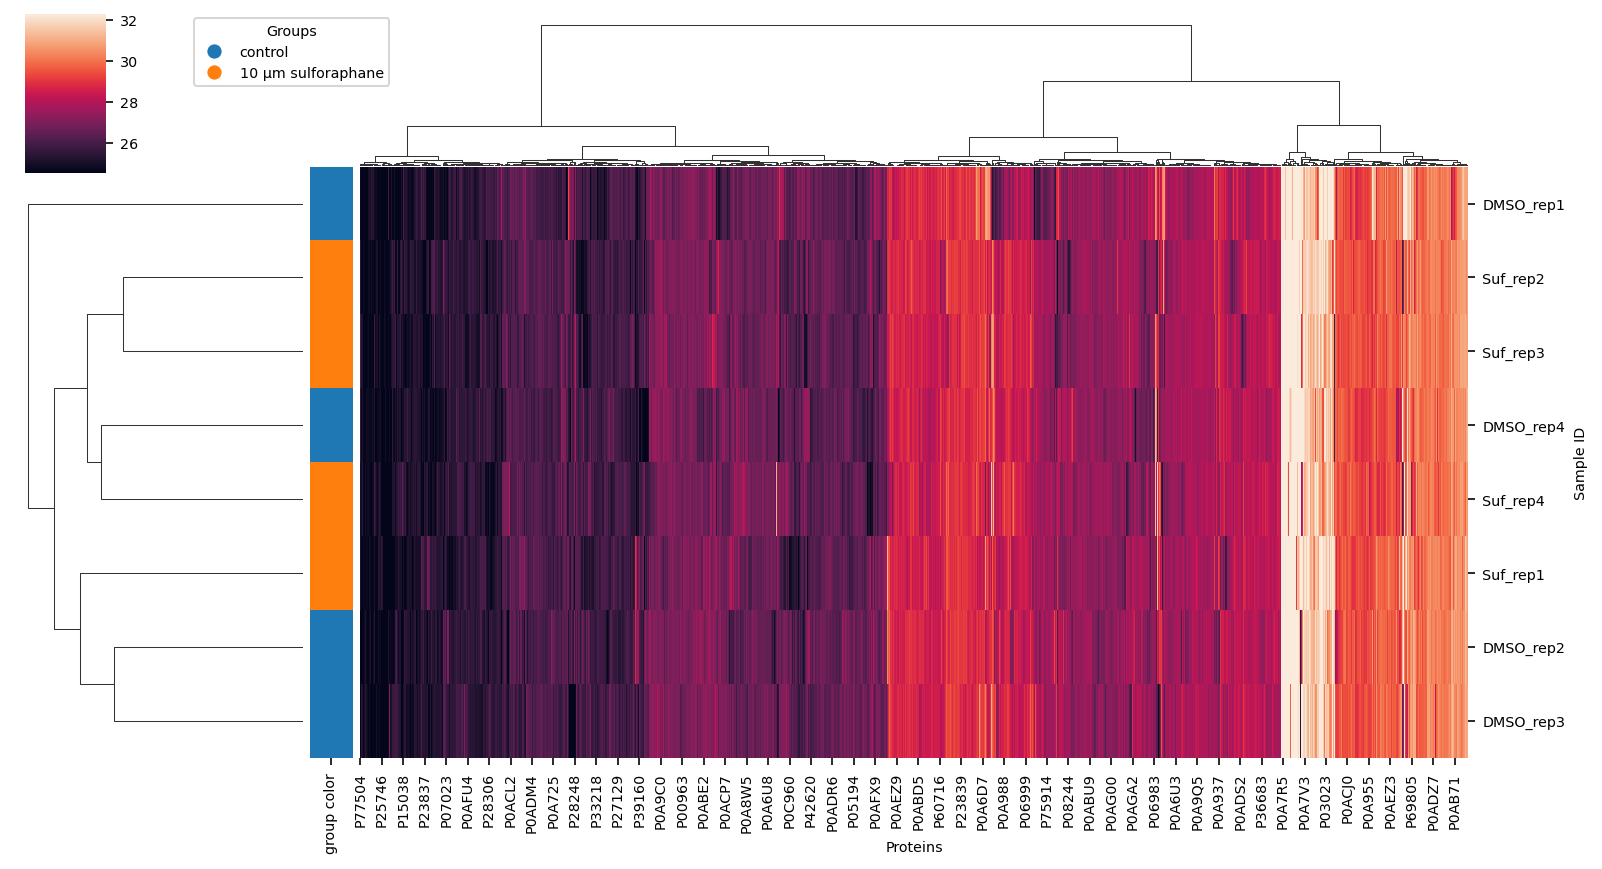

In [26]:
vuecore.set_font_sizes(7)
cg = sns.clustermap(
    X,
    method="ward",
    row_colors=row_colors,
    figsize=(11, 6),
    robust=True,
    xticklabels=True,
    yticklabels=True,
)
fig = cg.figure
cg.ax_heatmap.set_xlabel("Proteins")
cg.ax_heatmap.set_ylabel("Sample ID")
vuecore.select_xticks(cg.ax_heatmap)
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=lut[name], markersize=8)
    for name in lut
]
cg.ax_cbar.legend(
    handles, _group_labels, title="Groups", loc="lower left", bbox_to_anchor=(2, 0.5)
)
fname = out_dir_subsection / "clustermap_ward.png"
# vuecore.savefig(fig, fname, pdf=True, dpi=600, tight_layout=False)
fig.savefig(
    out_dir_subsection / f"clustermap_ward_{normalization_method}.png",
    bbox_inches="tight",
    dpi=300,
)

# Differential Regulation

In [27]:
out_dir_subsection = out_dir / "2_differential_regulation"
out_dir_subsection.mkdir(parents=True, exist_ok=True)

## Retain all proteins with at least 3 observations in each group
- this is a requirement for a standard t-test
- you could look into imputation methods to fill in missing values)
  - protein in at least two samples per group?
  - missing all in one condition?

Let's not impute, but filter for proteins with at least 3 observations in each group

In [28]:
group_counts = proteins.groupby(label_suf).count()
group_counts

UniprotID,A5A613,P00350,P00363,P00370,P00393,P00448,P00452,P00490,P00509,P00547,...,Q47319,Q47536,Q47622,Q47679,Q47710,Q57261,Q59385-2,Q59385,Q7DFV3,Q93K97
label_suf,,,,,,,,,,,,,,,,,,,,,
10 µm sulforaphane,0,4,4,4,4,4,3,4,4,2,...,1,1,2,2,4,4,0,4,4,4
control,1,4,4,4,4,4,1,4,4,2,...,0,0,3,1,4,4,3,4,4,4


Then we can filter the proteins to only those with at least 3 observations in each grou

In [29]:
mask = group_counts.groupby("label_suf").transform(lambda x: x >= 3).all(axis=0)
mask

UniprotID
A5A613      False
P00350       True
P00363       True
P00370       True
P00393       True
            ...  
Q57261       True
Q59385-2    False
Q59385       True
Q7DFV3       True
Q93K97       True
Length: 2269, dtype: bool

In [30]:
view = proteins.loc[:, mask].join(label_suf)
group = "label_suf"
diff_reg = acore.differential_regulation.run_anova(
    view,
    alpha=0.15,
    drop_cols=[],
    subject=None,
    group=group,
).sort_values("pvalue", ascending=True)
diff_reg["rejected"] = diff_reg["rejected"].astype(bool)
diff_reg.sort_values("pvalue")

,identifier,T-statistics,pvalue,mean_group1,mean_group2,std(group1),std(group2),log2FC,test,correction,padj,rejected,group1,group2,FC,-log10 pvalue,Method
957,P10384,-11.514,0.000,26.430,27.475,0.131,0.088,-1.045,t-Test,FDR correction BH,0.044,True,control,10 µm sulforaphane,0.485,4.589,Unpaired t-test
"1,678",Q46835,-8.146,0.000,26.723,27.677,0.194,0.058,-0.954,t-Test,FDR correction BH,0.127,True,control,10 µm sulforaphane,0.516,3.735,Unpaired t-test
120,P08200,-7.471,0.000,28.759,29.455,0.072,0.145,-0.696,t-Test,FDR correction BH,0.127,True,control,10 µm sulforaphane,0.617,3.527,Unpaired t-test
"1,542",P75726,7.460,0.000,28.082,26.852,0.222,0.180,1.230,t-Test,FDR correction BH,0.127,True,control,10 µm sulforaphane,2.345,3.524,Unpaired t-test
38,P02943,-7.006,0.000,26.117,27.920,0.428,0.124,-1.802,t-Test,FDR correction BH,0.143,True,control,10 µm sulforaphane,0.287,3.375,Unpaired t-test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983,P14407,-0.003,0.998,28.561,28.562,0.393,0.656,-0.001,t-Test,FDR correction BH,0.999,False,control,10 µm sulforaphane,0.999,0.001,Unpaired t-test
560,P0ABB0,0.002,0.998,31.306,31.305,0.318,0.051,0.000,t-Test,FDR correction BH,0.999,False,control,10 µm sulforaphane,1.000,0.001,Unpaired t-test
"1,531",P69797,0.002,0.998,30.255,30.254,0.391,0.328,0.001,t-Test,FDR correction BH,0.999,False,control,10 µm sulforaphane,1.000,0.001,Unpaired t-test
452,P0A9L3,-0.002,0.998,30.452,30.453,0.433,0.106,-0.001,t-Test,FDR correction BH,0.999,False,control,10 µm sulforaphane,1.000,0.001,Unpaired t-test


In [31]:
diff_reg.sort_values("pvalue").head(20)

,identifier,T-statistics,pvalue,mean_group1,mean_group2,std(group1),std(group2),log2FC,test,correction,padj,rejected,group1,group2,FC,-log10 pvalue,Method
957,P10384,-11.514,0.000,26.430,27.475,0.131,0.088,-1.045,t-Test,FDR correction BH,0.044,True,control,10 µm sulforaphane,0.485,4.589,Unpaired t-test
"1,678",Q46835,-8.146,0.000,26.723,27.677,0.194,0.058,-0.954,t-Test,FDR correction BH,0.127,True,control,10 µm sulforaphane,0.516,3.735,Unpaired t-test
120,P08200,-7.471,0.000,28.759,29.455,0.072,0.145,-0.696,t-Test,FDR correction BH,0.127,True,control,10 µm sulforaphane,0.617,3.527,Unpaired t-test
"1,542",P75726,7.460,0.000,28.082,26.852,0.222,0.180,1.230,t-Test,FDR correction BH,0.127,True,control,10 µm sulforaphane,2.345,3.524,Unpaired t-test
38,P02943,-7.006,0.000,26.117,27.920,0.428,0.124,-1.802,t-Test,FDR correction BH,0.143,True,control,10 µm sulforaphane,0.287,3.375,Unpaired t-test
"1,455",P62768,-6.288,0.001,28.999,29.682,0.147,0.118,-0.682,t-Test,FDR correction BH,0.213,False,control,10 µm sulforaphane,0.623,3.123,Unpaired t-test
"1,508",P68066,-5.856,0.001,31.551,32.216,0.101,0.169,-0.665,t-Test,FDR correction BH,0.235,False,control,10 µm sulforaphane,0.630,2.960,Unpaired t-test
579,P0ABK5,-5.841,0.001,29.630,30.524,0.246,0.100,-0.894,t-Test,FDR correction BH,0.235,False,control,10 µm sulforaphane,0.538,2.955,Unpaired t-test
"1,099",P25437,-5.304,0.002,29.088,29.744,0.183,0.112,-0.657,t-Test,FDR correction BH,0.324,False,control,10 µm sulforaphane,0.634,2.739,Unpaired t-test
"1,108",P25539,-5.230,0.002,26.862,27.166,0.061,0.080,-0.304,t-Test,FDR correction BH,0.324,False,control,10 µm sulforaphane,0.810,2.708,Unpaired t-test


<Axes: title={'center': 'label_suf'}, xlabel='log2FC', ylabel='-log10 pvalue'>

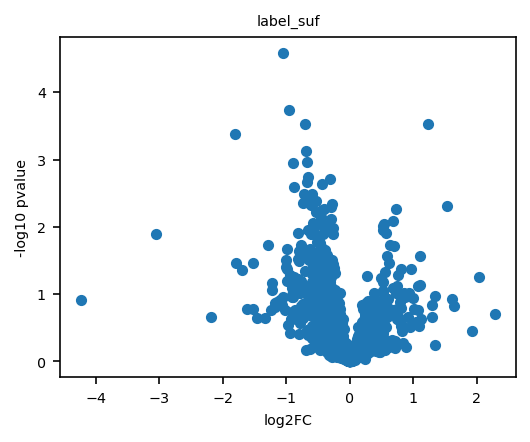

In [32]:
diff_reg.plot(x="log2FC", y="-log10 pvalue", kind="scatter", title=group)

# Interactive Volcano Plot

In [33]:
str_cols = diff_reg.dtypes[diff_reg.dtypes == "object"].index.tolist()
hover_data = {
    "rejected": ":.0f",
    **{
        c: ":.4f"
        for c in [
            "padj",
            "FC",
        ]
    },
    **{c: True for c in str_cols},
}
fig = px.scatter(
    diff_reg,
    x="log2FC",
    y="-log10 pvalue",
    color="rejected",
    hover_data=hover_data,
    width=1200,
    height=800,
    title=f"Volcano plot for {view_name}s",
)
fig

Save result to subsection folder

In [34]:
fig.write_json(
    out_dir_subsection / "0_volcano_plot.json",
    pretty=False,
)
diff_reg.to_csv(out_dir_subsection / "1_differential_regulation.csv")

# Enrichment Analysis

In [35]:
out_dir_subsection = out_dir / "uniprot_annotations"
out_dir_subsection.mkdir(parents=True, exist_ok=True)

## Fetch the annotations from UniProt API.

In [36]:
fname_annotations = out_dir_subsection / "annotations.csv"
try:
    annotations = pd.read_csv(fname_annotations, index_col=0)
    print(f"Loaded annotations from {fname_annotations}")
except FileNotFoundError:
    print(f"Fetching annotations for {proteins.columns.size} UniProt IDs.")
    FIELDS = "go_p,go_c,go_f"
    annotations = fetch_annotations(proteins.columns, fields=FIELDS)
    annotations = process_annotations(annotations, fields=FIELDS)
    # cache the annotations
    fname_annotations.parent.mkdir(exist_ok=True, parents=True)
    annotations.to_csv(fname_annotations, index=True)

annotations

Fetching annotations for 2269 UniProt IDs.


Fetched: 500 / 2269


Fetched: 1000 / 2269


Fetched: 1500 / 2269


Fetched: 2000 / 2269
Fetched: 2269 / 2269


,identifier,source,annotation
3,P00350,Gene Ontology (biological process),D-gluconate metabolic process [GO:0019521]
4,P00350,Gene Ontology (cellular component),cytosol [GO:0005829]
5,P00350,Gene Ontology (molecular function),guanosine tetraphosphate binding [GO:0097216]
6,P00350,Gene Ontology (molecular function),identical protein binding [GO:0042802]
7,P00350,Gene Ontology (molecular function),NADP binding [GO:0050661]
...,...,...,...
"15,989",Q93K97,Gene Ontology (molecular function),magnesium ion binding [GO:0000287]
"15,990",Q93K97,Gene Ontology (molecular function),protein homodimerization activity [GO:0042803]
"15,991",Q93K97,Gene Ontology (molecular function),pyrophosphatase activity [GO:0016462]
"15,992",Q93K97,Gene Ontology (biological process),response to heat [GO:0009408]


## Run the enrichment analysis
- background is the set of identified proteins in the experiment (not the whole proteome
  of the organisim, here E. coli)
- The enrichment is performed separately for the up- and down-regulated proteins ('rejected'),
  which are few in our example where we had to set the adjusted p-value to 0.15.

In the enrichment we set the cutoff for the adjusted p-value to 0.2, which is
a bit arbitrary to see some results.

In [37]:
enriched = acore.enrichment_analysis.run_up_down_regulation_enrichment(
    regulation_data=diff_reg,
    annotation=annotations,
    min_detected_in_set=1,
    lfc_cutoff=1,
    pval_col="padj",  # toggle if it does not work
    correction_alpha=0.2,  # adjust the p-value to see more or less results
)
enriched

,terms,identifiers,foreground,background,foreground_pop,background_pop,pvalue,padj,rejected,direction,comparison
0,citrate CoA-transferase activity [GO:0008814],P75726,1,0,1,"1,696",0.001,0.002,True,upregulated,control~10 µm sulforaphane
1,citrate metabolic process [GO:0006101],P75726,1,2,1,"1,696",0.002,0.002,True,upregulated,control~10 µm sulforaphane
3,ATP-independent citrate lyase complex [GO:0009...,P75726,1,2,1,"1,696",0.002,0.002,True,upregulated,control~10 µm sulforaphane
4,acetyl-CoA metabolic process [GO:0006084],P75726,1,2,1,"1,696",0.002,0.002,True,upregulated,control~10 µm sulforaphane
5,citrate (pro-3S)-lyase activity [GO:0008815],P75726,1,1,1,"1,696",0.001,0.002,True,upregulated,control~10 µm sulforaphane
2,cytoplasm [GO:0005737],P75726,1,29,1,"1,696",0.018,0.018,True,upregulated,control~10 µm sulforaphane
0,long-chain fatty acid transporting porin acti...,P10384,1,0,2,"1,696",0.001,0.002,True,downregulated,control~10 µm sulforaphane
14,cell outer membrane [GO:0009279],"P02943,P10384",2,43,2,"1,696",0.001,0.002,True,downregulated,control~10 µm sulforaphane
15,ligand-gated channel activity [GO:0022834],P10384,1,0,2,"1,696",0.001,0.002,True,downregulated,control~10 µm sulforaphane
5,maltose transporting porin activity [GO:0015481],P02943,1,0,2,"1,696",0.001,0.002,True,downregulated,control~10 µm sulforaphane


In [38]:
fig = get_enrichment_plots(
    enriched,
    identifier="anything",  # ToDo: figure out what this does
    args=dict(title="Enrichment Analysis"),
)
fig = fig[0]
fig.write_json(
    out_dir_subsection / "enrichment_analysis.json",
    pretty=True,
)
fig

# Check for Maltose Uptake

In [39]:
out_dir_subsection = out_dir / "3_maltose_uptake"
out_dir_subsection.mkdir(parents=True, exist_ok=True)

apply filtering of 'differentially abundant proteins' as described in the paper
> Differentially abundant proteins were determined as those with log2 fold-change
> > 1 and < -1, and p < 0.05
This means not multiple testing correction was applied.

In [40]:
view = diff_reg.query("pvalue < 0.05 and FC > 1")  # .shape[0]
view.to_csv(
    out_dir_subsection / "1_differently_regulated_as_in_paper.csv",
    index=False,
)
view

,identifier,T-statistics,pvalue,mean_group1,mean_group2,std(group1),std(group2),log2FC,test,correction,padj,rejected,group1,group2,FC,-log10 pvalue,Method
"1,542",P75726,7.460,0.000,28.082,26.852,0.222,0.180,1.230,t-Test,FDR correction BH,0.127,True,control,10 µm sulforaphane,2.345,3.524,Unpaired t-test
"1,553",P75825,4.344,0.005,26.903,25.378,0.327,0.512,1.525,t-Test,FDR correction BH,0.364,False,control,10 µm sulforaphane,2.877,2.314,Unpaired t-test
580,P0ABK9,4.238,0.005,26.363,25.637,0.230,0.187,0.726,t-Test,FDR correction BH,0.364,False,control,10 µm sulforaphane,1.654,2.264,Unpaired t-test
"1,288",P37349,3.868,0.008,25.935,25.251,0.296,0.079,0.683,t-Test,FDR correction BH,0.438,False,control,10 µm sulforaphane,1.606,2.082,Unpaired t-test
"1,610",P76440,3.796,0.009,27.182,26.639,0.233,0.084,0.543,t-Test,FDR correction BH,0.438,False,control,10 µm sulforaphane,1.457,2.045,Unpaired t-test
961,P11349,3.722,0.010,27.459,26.939,0.223,0.094,0.521,t-Test,FDR correction BH,0.445,False,control,10 µm sulforaphane,1.435,2.007,Unpaired t-test
"1,632",P77252,3.624,0.011,26.540,26.012,0.131,0.215,0.528,t-Test,FDR correction BH,0.445,False,control,10 µm sulforaphane,1.441,1.957,Unpaired t-test
142,P09152,3.542,0.012,26.822,26.250,0.228,0.162,0.572,t-Test,FDR correction BH,0.445,False,control,10 µm sulforaphane,1.487,1.914,Unpaired t-test
"1,098",P25397,3.191,0.019,27.632,27.003,0.177,0.292,0.629,t-Test,FDR correction BH,0.577,False,control,10 µm sulforaphane,1.546,1.726,Unpaired t-test
261,P0A7E3,3.181,0.019,27.335,26.631,0.146,0.355,0.704,t-Test,FDR correction BH,0.577,False,control,10 µm sulforaphane,1.629,1.720,Unpaired t-test


Let's find the proteins highlighted in the volcano plot in Figure 3.

In [41]:
highlighted_genes = ["LamB", "MalE", "Malk", "CitF", "CitT", "CitE", "Frd"]
highlighted_genes = "|".join([p.upper() for p in highlighted_genes])
highlighted_genes = proteins_meta.query(
    f"`GeneName`.str.contains('{highlighted_genes}')"
)
highlighted_genes

,Source,ProteinName,GeneName
identifier,,,
sp|P00363|FRDA_ECOLI,sp,P00363,FRDA
sp|P02943|LAMB_ECOLI,sp,P02943,LAMB
sp|P0A8Q0|FRDC_ECOLI,sp,P0A8Q0,FRDC
sp|P0A8Q3|FRDD_ECOLI,sp,P0A8Q3,FRDD
sp|P0A9I1|CITE_ECOLI,sp,P0A9I1,CITE
sp|P0AC47|FRDB_ECOLI,sp,P0AC47,FRDB
sp|P0AE74|CITT_ECOLI,sp,P0AE74,CITT
sp|P0AEX9|MALE_ECOLI,sp,P0AEX9,MALE
sp|P68187|MALK_ECOLI,sp,P68187,MALK


In [42]:
highlighted_proteins = "|".join([p.upper() for p in highlighted_genes["ProteinName"]])
view = diff_reg.query(f"`identifier`.str.contains('{highlighted_proteins}')")
view = view.set_index("identifier").join(proteins_meta.set_index("ProteinName"))
view.to_csv(
    out_dir_subsection / "2_highlighted_proteins_in_figure3.csv",
    index=False,
)
sel_cols = [
    "identifier",
    "GeneName",
    "log2FC",
    "pvalue",
    "padj",
    "rejected",
    "group1",
    "group2",
    "Method",
]
view.reset_index()[sel_cols].sort_values("log2FC", ascending=False)

,identifier,GeneName,log2FC,pvalue,padj,rejected,group1,group2,Method
1,P0A9I1,CITE,1.102,0.027,0.589,False,control,10 µm sulforaphane,Unpaired t-test
2,P0AE74,CITT,0.872,0.110,0.754,False,control,10 µm sulforaphane,Unpaired t-test
3,P0A8Q0,FRDC,0.815,0.159,0.756,False,control,10 µm sulforaphane,Unpaired t-test
4,P00363,FRDA,0.095,0.676,0.965,False,control,10 µm sulforaphane,Unpaired t-test
5,P0AC47,FRDB,0.062,0.808,0.981,False,control,10 µm sulforaphane,Unpaired t-test
6,P0AEX9,MALE,0.012,0.959,0.997,False,control,10 µm sulforaphane,Unpaired t-test
0,P02943,LAMB,-1.802,0.000,0.143,True,control,10 µm sulforaphane,Unpaired t-test


Let's see their original data

In [43]:
view_proteins = (
    (
        proteins[highlighted_genes["ProteinName"].to_list()].T.join(
            proteins_meta.set_index("ProteinName")["GeneName"]
        )
    )
    .set_index("GeneName", append=True)
    .T
)  # to check]
view_proteins.to_csv(
    out_dir_subsection / "3_highlighted_proteins_in_figure3_intensities.csv",
    index=True,
)
view_proteins

UniprotID,P00363,P02943,P0A8Q0,P0A8Q3,P0A9I1,P0AC47,P0AE74,P0AEX9,P68187
GeneName,FRDA,LAMB,FRDC,FRDD,CITE,FRDB,CITT,MALE,MALK
DMSO_rep1,30.247,26.752,30.348,27.389,29.031,31.223,27.544,27.099,NaN
DMSO_rep2,30.262,26.012,28.815,27.061,27.933,30.947,26.364,26.785,24.881
DMSO_rep3,29.970,26.151,30.569,27.291,27.569,30.664,25.292,26.854,NaN
DMSO_rep4,29.471,25.555,29.097,24.906,27.865,30.815,26.608,27.037,25.423
Suf_rep1,30.005,27.844,28.350,26.703,27.296,31.360,25.485,26.518,26.047
Suf_rep2,30.086,28.095,29.444,NaN,26.744,30.317,25.691,26.864,24.964
Suf_rep3,29.904,27.971,29.172,NaN,26.563,30.818,25.549,27.536,25.545
Suf_rep4,29.575,27.769,28.602,25.294,27.386,30.907,25.594,26.809,26.134


How to explain the differences?